# Лабораторная работа 7. Полносвязные нейронные сети (FCNN). Решение задачи классификации

## Загрузка данных и понижение размерности

In [82]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.model_selection import train_test_split
from umap import UMAP
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
data = pd.read_csv("datasets/neo.csv", index_col = 0)

X, y = data.drop("hazardous", axis=1), data["hazardous"]

X = StandardScaler().fit_transform(X)

umap = UMAP(n_components=3, random_state=42)
X = umap.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
rus = RandomUnderSampler(sampling_strategy=0.5, random_state=42)

X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [54]:
X_train_res.shape

(21216, 3)

## FCNN (MLP) из библиотеки Scikit-learn

In [55]:
columns = [
    'Classifier', 'Search strategy',
    'Train_F1', 'Train_Accuracy', 'Train_Precision', 'Train_Recall',
    'Test_F1', 'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Epochs', 'Solver'
]
table = pd.DataFrame(columns=columns)
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver


In [56]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score


def input_into_table(name, search_name, model, X_train, y_train, X_test, y_test):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    new_row = {
        'Classifier': name,
        'Search strategy': search_name,
        'Train_F1': round(f1_score(y_train, train_pred), 2),
        'Train_Accuracy': round(accuracy_score(y_train, train_pred), 4),
        'Train_Precision': round(precision_score(y_train, train_pred), 4),
        'Train_Recall': round(recall_score(y_test, test_pred), 2),
        'Test_F1': round(f1_score(y_test, test_pred), 4),
        'Test_Accuracy': round(accuracy_score(y_test, test_pred), 4),
        'Test_Precision': round(precision_score(y_test, test_pred), 4),
        'Test_Recall': round(recall_score(y_test, test_pred), 4),
        'Epochs': model.n_iter_,
        'Solver': model.solver
    }

    table.loc[len(table)] = new_row

### Optuna

In [58]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier


def objective(trial):
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes',
                                                        [(100,), (50, 50), (100, 50), (100, 100, 100)]),

        'solver': trial.suggest_categorical('solver', ['adam', 'sgd', 'lbfgs']),

        'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),

        'alpha': trial.suggest_float('alpha', 1e-5, 1e-2, log=True),

        'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)
    }

    classifier = MLPClassifier(**params, random_state=15, max_iter=1000)

    score = cross_val_score(classifier, X_train, y_train, cv=3, n_jobs=-1, scoring="f1").mean()

    return score

study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=10)

print(f"Лучшие параметры: {study.best_params}")

[I 2026-05-11 20:31:00,956] A new study created in memory with name: no-name-fbb3b74a-54b9-490b-bc5f-436674221f81
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  optuna_warn(message)
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 50) which is of type tuple.
  optuna_warn(message)
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50) which is of type tuple.
  optuna_warn(messa

Лучшие параметры: {'hidden_layer_sizes': (50, 50), 'solver': 'adam', 'activation': 'relu', 'alpha': 0.006188915511343217, 'learning_rate': 'constant', 'learning_rate_init': 0.003915211165791473}


In [59]:
model = MLPClassifier(**study.best_params, random_state=15)
model.fit(X_train, y_train)
input_into_table("MLPClassifier", "Optuna", model, X_train, y_train, X_test, y_test)
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier,Optuna,0.27,0.9107,0.6653,0.15,0.2514,0.9105,0.6757,0.1544,48,adam


In [60]:
n_layers = len(model.coefs_)

print(f"Количество скрытых слоев: {model.n_layers_ - 2}")
print(f"Архитектура слоев (нейроны):")
for i, weights in enumerate(model.coefs_):
    print(f" Связи между слоем {i} и {i+1}: {weights.shape[0]} -> {weights.shape[1]}")

Количество скрытых слоев: 2
Архитектура слоев (нейроны):
 Связи между слоем 0 и 1: 3 -> 50
 Связи между слоем 1 и 2: 50 -> 50
 Связи между слоем 2 и 3: 50 -> 1


In [61]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

def make_graphic(model, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    cm_train = confusion_matrix(y_train, model.predict(X_train))
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
    disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title("Train")
    axes[0].grid(False)

    cm_test = confusion_matrix(y_test, model.predict(X_test))
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
    disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
    axes[1].set_title("Test")
    axes[1].grid(False)

    plt.suptitle(name)
    plt.tight_layout()
    plt.show()


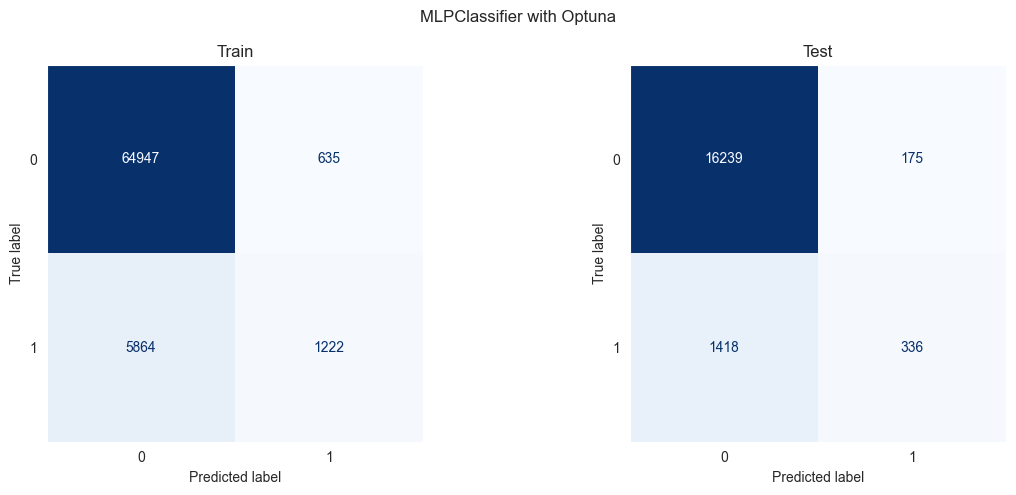

In [31]:
make_graphic(model, "MLPClassifier with Optuna")

In [62]:
print(f"Архитектура сети: {model.hidden_layer_sizes}")

print(f"Количество слоев: {model.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in model.coefs_]}")

Архитектура сети: (50, 50)
Количество слоев: 4
Количество весов (коэффициентов): [(3, 50), (50, 50), (50, 1)]


Text(0, 0.5, 'Loss')

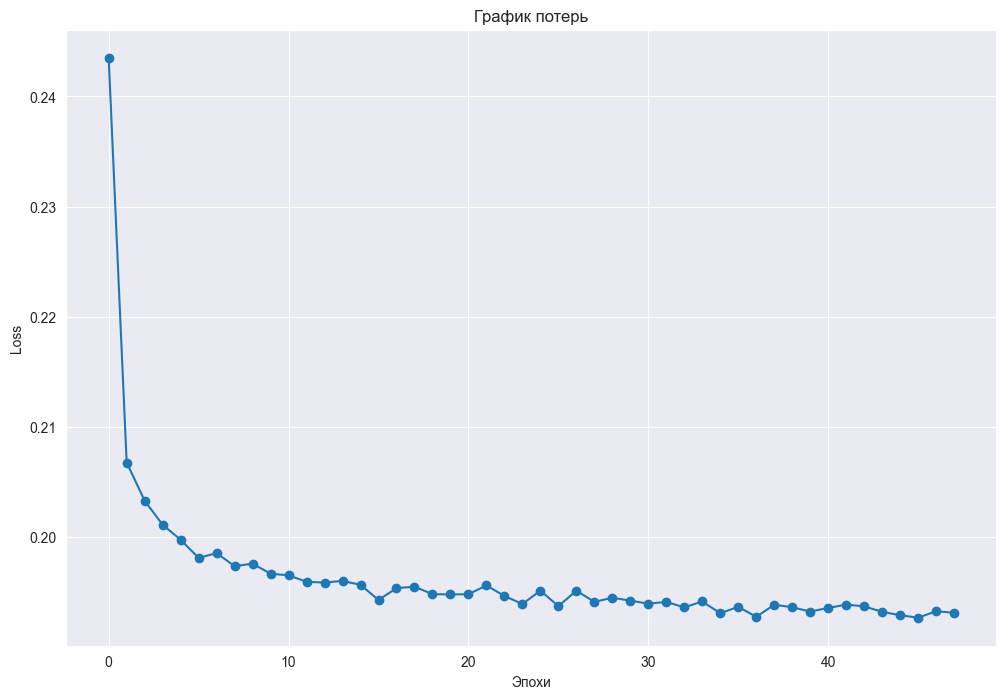

In [63]:
plt.figure(figsize=(12, 8))
plt.plot(model.loss_curve_, marker='o')
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss")

### RandomizedSearchCV

In [64]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'hidden_layer_sizes': [(100,), (50, 50), (100, 50), (100, 100, 100)],
    'solver': ['adam', 'sgd', 'lbfgs'],
    'activation': ['relu', 'tanh', 'logistic'],
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'learning_rate': ['constant', 'adaptive'],
}

mlp = MLPClassifier(max_iter=1000)

rs = RandomizedSearchCV(estimator=mlp,
                        param_distributions=param_dist,
                        n_jobs=-1,
                        cv=3,
                        scoring="f1",
                        verbose=3)

rs.fit(X_train, y_train)
input_into_table("MLPClassifier", "RandomizedSearch", rs.best_estimator_, X_train, y_train, X_test, y_test)
table

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier,Optuna,0.27,0.9107,0.6653,0.15,0.2514,0.9105,0.6757,0.1544,48,adam
1,MLPClassifier,RandomizedSearch,0.28,0.9092,0.6105,0.17,0.2634,0.9086,0.6099,0.1680,41,adam


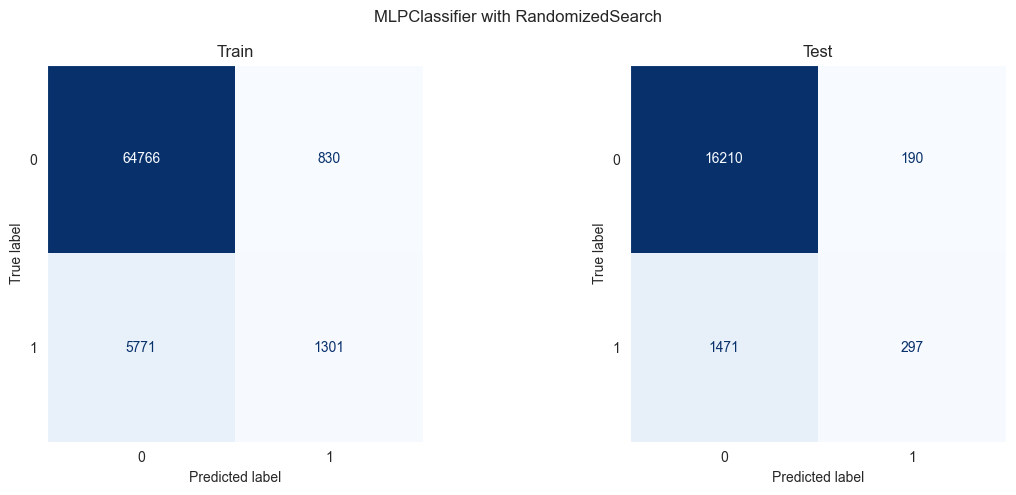

In [68]:
make_graphic(rs.best_estimator_, "MLPClassifier with RandomizedSearch")

In [69]:
print(f"Архитектура сети: {rs.best_estimator_.hidden_layer_sizes}")

print(f"Количество слоев: {rs.best_estimator_.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in rs.best_estimator_.coefs_]}")

Архитектура сети: (50, 50)
Количество слоев: 4
Количество весов (коэффициентов): [(3, 50), (50, 50), (50, 1)]


Text(0, 0.5, 'Loss')

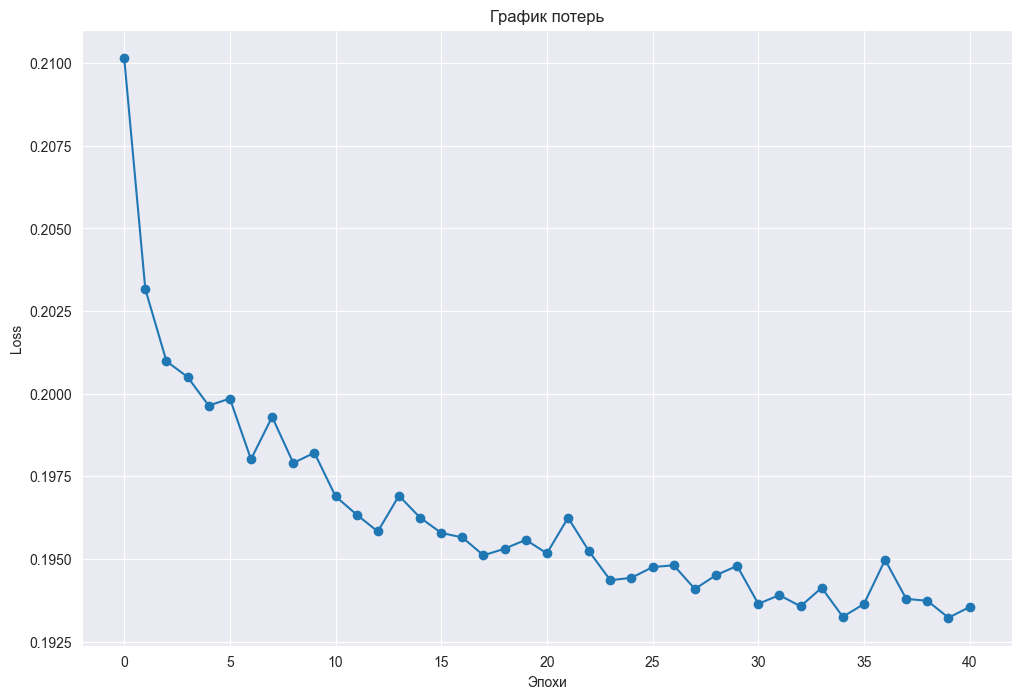

In [70]:
plt.figure(figsize=(12, 8))
plt.plot(rs.best_estimator_.loss_curve_, marker='o')
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss")

### Hyperport

In [71]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import numpy as np

layers = [(100,), (50, 50), (100, 50), (100, 100, 100)]
solvers = ['adam', 'sgd',]
activations = ['relu', 'tanh']
learning_rates = ['constant', 'adaptive']

space = {
    'hidden_layer_sizes': hp.choice('hidden_layer_sizes', layers),
    'solver': hp.choice('solver', solvers),
    'activation': hp.choice('activation', activations),
    'alpha': hp.loguniform('alpha', np.log(1e-5), np.log(1e-2)),
    'learning_rate': hp.choice('learning_rate', learning_rates),
}

def objective(params):
    model = MLPRegressor(**params, max_iter=2000, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='r2').mean()
    return {'loss': -score, 'status': STATUS_OK}

trials = Trials()
best_indices = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=15, trials=trials)

best_params = {
    'hidden_layer_sizes': layers[best_indices['hidden_layer_sizes']],
    'solver': solvers[best_indices['solver']],
    'activation': activations[best_indices['activation']],
    'alpha': best_indices['alpha'],
    'learning_rate': learning_rates[best_indices['learning_rate']],
}


best_model_hyperopt = MLPClassifier(**best_params, max_iter=2000, random_state=42).fit(X_train, y_train)
input_into_table("MLPClassifier", "Hyperopt", best_model_hyperopt, X_train, y_train, X_test, y_test)

print("Лучшие параметры Hyperopt:", best_params)

100%|██████████| 15/15 [06:32<00:00, 26.15s/trial, best loss: -0.2639681100845337]
Лучшие параметры Hyperopt: {'hidden_layer_sizes': (100, 100, 100), 'solver': 'adam', 'activation': 'relu', 'alpha': 1.0740272520578199e-05, 'learning_rate': 'constant'}


In [72]:
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier,Optuna,0.27,0.9107,0.6653,0.15,0.2514,0.9105,0.6757,0.1544,48,adam
1,MLPClassifier,RandomizedSearch,0.28,0.9092,0.6105,0.17,0.2634,0.9086,0.6099,0.1680,41,adam
2,MLPClassifier,Hyperopt,0.28,0.9111,0.6651,0.16,0.2645,0.9109,0.6736,0.1646,103,adam


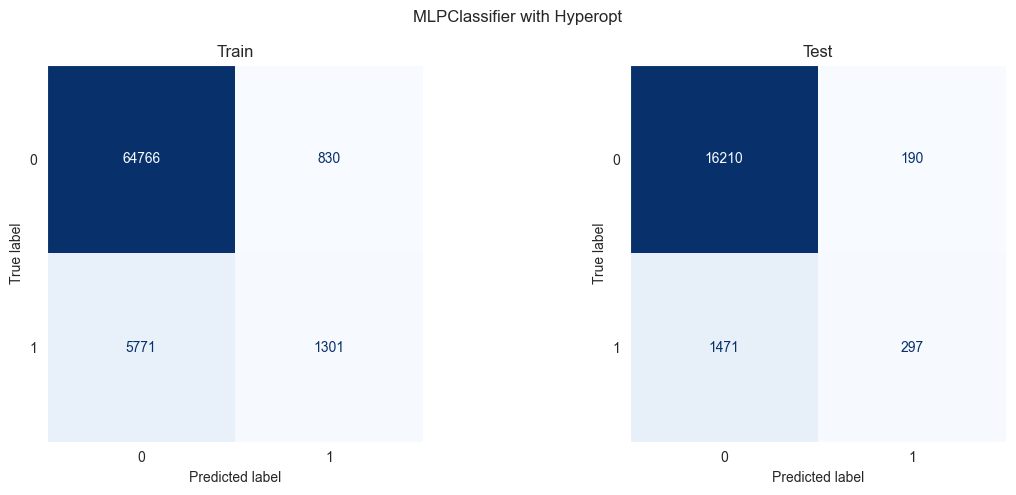

In [73]:
make_graphic(rs.best_estimator_, "MLPClassifier with Hyperopt")

In [74]:
print(f"Архитектура сети: {best_model_hyperopt.hidden_layer_sizes}")

print(f"Количество слоев: {best_model_hyperopt.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in best_model_hyperopt.coefs_]}")

Архитектура сети: (100, 100, 100)
Количество слоев: 5
Количество весов (коэффициентов): [(3, 100), (100, 100), (100, 100), (100, 1)]


Text(0, 0.5, 'Loss')

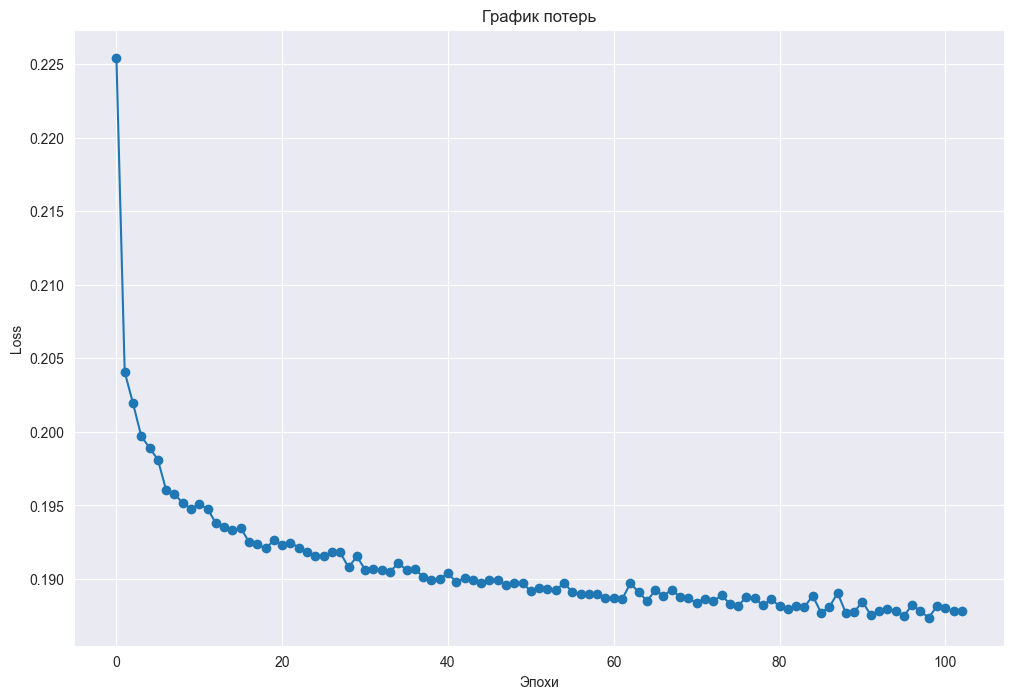

In [75]:
plt.figure(figsize=(12, 8))
plt.plot(best_model_hyperopt.loss_curve_, marker='o')
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss")

## Keras

In [98]:
import keras
def input_into_table_keras(name, search_name, model, X_train, y_train, X_test, y_test, history):
    train_pred = (model.predict(X_train) > 0.5).astype("int32")
    test_pred = (model.predict(X_test) > 0.5).astype("int32")

    new_row = {
        'Classifier': name,
        'Search strategy': search_name,
        'Train_F1': round(f1_score(y_train, train_pred), 2),
        'Train_Accuracy': round(accuracy_score(y_train, train_pred), 4),
        'Train_Precision': round(precision_score(y_train, train_pred), 4),
        'Train_Recall': round(recall_score(y_train, train_pred), 2),
        'Test_F1': round(f1_score(y_test, test_pred), 4),
        'Test_Accuracy': round(accuracy_score(y_test, test_pred), 4),
        'Test_Precision': round(precision_score(y_test, test_pred), 4),
        'Test_Recall': round(recall_score(y_test, test_pred), 4),
        'Epochs': len(history.history['loss']),
        'Solver': model.optimizer.__class__.__name__
    }

    table.loc[len(table)] = new_row

optimizers_dict = {
    "adam": keras.optimizers.Adam,
    "sgd": keras.optimizers.SGD,
    "rmsprop": keras.optimizers.RMSprop,
}

In [103]:
def make_graphic_keras(model, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))


    y_train_pred = (model.predict(X_train) > 0.5).astype("int32")
    y_test_pred = (model.predict(X_test) > 0.5).astype("int32")


    cm_train = confusion_matrix(y_train, y_train_pred)
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=["Safe", "Hazardous"])
    disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title("Train")

    cm_test = confusion_matrix(y_test, y_test_pred)
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["Safe", "Hazardous"])
    disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
    axes[1].set_title("Test")

    plt.suptitle(name)
    plt.tight_layout()
    plt.show()

In [93]:
import numpy as np
import pandas as pd
import optuna

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import KFold

def objective(trial):
    n_layers = trial.suggest_int("n_layers", 1, 5)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    activation = trial.suggest_categorical("activation", ["relu", "tanh", "elu", "sigmoid"])
    opt_name = trial.suggest_categorical("optimizer", list(optimizers_dict.keys()))
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X_train):
        X_t, X_v = X_train[train_idx], X_train[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = keras.Sequential()
        model.add(layers.Input(shape=(X_t.shape[1],)))

        for i in range(n_layers):
            num_hidden = trial.suggest_int(f"n_units_l{i}", 16, 512, log=True)
            model.add(layers.Dense(num_hidden, activation=activation))
            dropout_rate = trial.suggest_float(f"dropout_l{i}", 0.0, 0.3)
            model.add(layers.Dropout(dropout_rate))

        model.add(layers.Dense(1, activation="sigmoid"))

        optimizer = optimizers_dict[opt_name](learning_rate=learning_rate)
        model.compile(
            optimizer=optimizer,
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        model.fit(
            X_t, y_t,
            validation_data=(X_v, y_v),
            epochs=15,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=3
        )

        y_pred_probs = model.predict(X_v, verbose=0)
        y_pred = (y_pred_probs > 0.5).astype("int32")
        score = f1_score(y_v, y_pred)
        scores.append(score)

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)

print(f"Лучшая ошибка: {study.best_value}")
print(f"Параметры: {study.best_params}")



[I 2026-05-11 21:13:29,716] A new study created in memory with name: no-name-031e33ed-88a0-4dea-9a83-087cdff1e574


Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15
Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15
Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15


[I 2026-05-11 21:13:58,979] Trial 0 finished with value: 0.0 and parameters: {'n_layers': 2, 'learning_rate': 0.00017885635868667308, 'activation': 'relu', 'optimizer': 'sgd', 'batch_size': 128, 'n_units_l0': 129, 'dropout_l0': 0.1923509808222791, 'n_units_l1': 206, 'dropout_l1': 0.1982637810481718}. Best is trial 0 with value: 0.0.


Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15
Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15
Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15


[I 2026-05-11 21:14:54,811] Trial 1 finished with value: 0.0 and parameters: {'n_layers': 3, 'learning_rate': 2.0356433253679934e-05, 'activation': 'relu', 'optimizer': 'sgd', 'batch_size': 64, 'n_units_l0': 371, 'dropout_l0': 0.05061660236297639, 'n_units_l1': 118, 'dropout_l1': 0.03134166617593746, 'n_units_l2': 114, 'dropout_l2': 0.29600297483334886}. Best is trial 0 with value: 0.0.


...

Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15
Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15
Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15


[I 2026-05-11 21:17:19,126] Trial 3 finished with value: 0.006159876802463951 and parameters: {'n_layers': 5, 'learning_rate': 0.006493778278250646, 'activation': 'relu', 'optimizer': 'adam', 'batch_size': 128, 'n_units_l0': 55, 'dropout_l0': 0.25754306286479844, 'n_units_l1': 127, 'dropout_l1': 0.18827514413042606, 'n_units_l2': 31, 'dropout_l2': 0.21573749142020812, 'n_units_l3': 163, 'dropout_l3': 0.20167751656632174, 'n_units_l4': 329, 'dropout_l4': 0.03824715521796844}. Best is trial 2 with value: 0.22163904639220403.


Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15
Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15
Epoch 1/15
Epoch 2/15
Epoch 3/15
Epoch 4/15
Epoch 5/15
Epoch 6/15
Epoch 7/15
Epoch 8/15
Epoch 9/15
Epoch 10/15
Epoch 11/15
Epoch 12/15
Epoch 13/15
Epoch 14/15
Epoch 15/15


[I 2026-05-11 21:17:42,923] Trial 4 finished with value: 0.03737292174097215 and parameters: {'n_layers': 1, 'learning_rate': 0.0016047799509490731, 'activation': 'tanh', 'optimizer': 'rmsprop', 'batch_size': 128, 'n_units_l0': 73, 'dropout_l0': 0.2661056580051043}. Best is trial 2 with value: 0.22163904639220403.


Лучшая ошибка: 0.22163904639220403
Параметры: {'n_layers': 3, 'learning_rate': 0.0008809059714932443, 'activation': 'elu', 'optimizer': 'adam', 'batch_size': 32, 'n_units_l0': 229, 'dropout_l0': 0.27526917564262365, 'n_units_l1': 147, 'dropout_l1': 0.10276577262829178, 'n_units_l2': 28, 'dropout_l2': 0.22509220466614518}


In [95]:
import keras
params = study.best_params
model = keras.Sequential()
model.add(layers.Input(shape=(X_train.shape[1],)))


for i in range(params["n_layers"]):
    model.add(layers.Dense(
        params[f"n_units_l{i}"],
        activation=params["activation"]
    ))
    if f"dropout_l{i}" in params:
        model.add(layers.Dropout(params[f"dropout_l{i}"]))

model.add(layers.Dense(1, activation="sigmoid"))

model.compile(
    optimizer=optimizers_dict[params["optimizer"]](learning_rate=params["learning_rate"]),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=study.best_params["batch_size"],
    verbose=2
)

Epoch 1/25
2271/2271 - 3s - 1ms/step - accuracy: 0.8976 - loss: 0.2222 - val_accuracy: 0.9033 - val_loss: 0.2066
Epoch 2/25
2271/2271 - 3s - 1ms/step - accuracy: 0.9028 - loss: 0.2091 - val_accuracy: 0.9086 - val_loss: 0.2029
Epoch 3/25
2271/2271 - 3s - 1ms/step - accuracy: 0.9046 - loss: 0.2061 - val_accuracy: 0.9061 - val_loss: 0.2018
Epoch 4/25
2271/2271 - 3s - 1ms/step - accuracy: 0.9044 - loss: 0.2045 - val_accuracy: 0.9060 - val_loss: 0.2013
Epoch 5/25
2271/2271 - 3s - 1ms/step - accuracy: 0.9057 - loss: 0.2028 - val_accuracy: 0.9086 - val_loss: 0.1998
Epoch 6/25
2271/2271 - 3s - 1ms/step - accuracy: 0.9060 - loss: 0.2020 - val_accuracy: 0.9049 - val_loss: 0.2032
Epoch 7/25
2271/2271 - 3s - 1ms/step - accuracy: 0.9065 - loss: 0.2011 - val_accuracy: 0.9032 - val_loss: 0.2055
Epoch 8/25
2271/2271 - 3s - 1ms/step - accuracy: 0.9063 - loss: 0.2008 - val_accuracy: 0.9043 - val_loss: 0.2006
Epoch 9/25
2271/2271 - 3s - 1ms/step - accuracy: 0.9070 - loss: 0.2008 - val_accuracy: 0.9061 - 

In [96]:
model.summary()

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_116 (Dense)               │ (None, 229)            │           916 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_85 (Dropout)            │ (None, 229)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ (None, 147)            │        33,810 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_86 (Dropout)            │ (None, 147)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_118 (Dense)               │ (None, 28)             │         4,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_87 (Dropout)            │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_119 (Dense)               │ (None, 1)              │            29 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,699 (455.86 KB)

 Trainable params: 38,899 (151.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 77,800 (303.91 KB)

In [99]:
input_into_table_keras("FCNN (Keras)", "Optuna", model, X_train, y_train, X_test, y_test, history)

2271/2271 ━━━━━━━━━━━━━━━━━━━━ 1s 546us/step
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step


Text(0, 0.5, 'Loss')

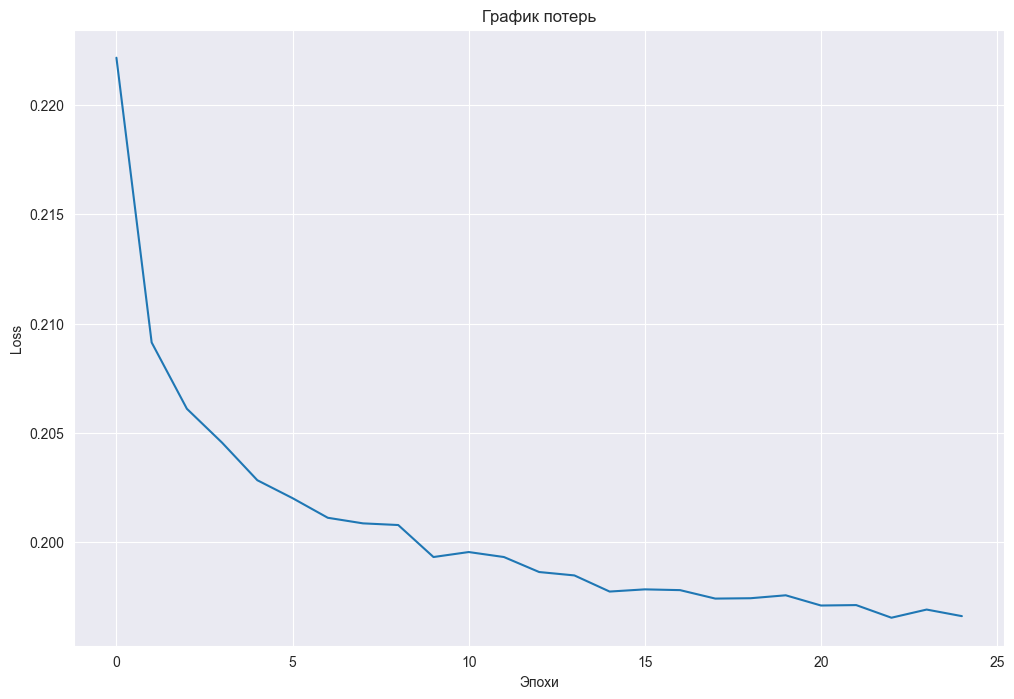

In [100]:
plt.figure(figsize=(12, 8))
plt.plot(history.history['loss'])
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss")

In [101]:
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier,Optuna,0.27,0.9107,0.6653,0.15,0.2514,0.9105,0.6757,0.1544,48,adam
1,MLPClassifier,RandomizedSearch,0.28,0.9092,0.6105,0.17,0.2634,0.9086,0.6099,0.1680,41,adam
2,MLPClassifier,Hyperopt,0.28,0.9111,0.6651,0.16,0.2645,0.9109,0.6736,0.1646,103,adam
3,FCNN (Keras),Optuna,0.25,0.9087,0.6235,0.16,0.2355,0.9100,0.6597,0.1433,25,Adam


2271/2271 ━━━━━━━━━━━━━━━━━━━━ 1s 506us/step
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step


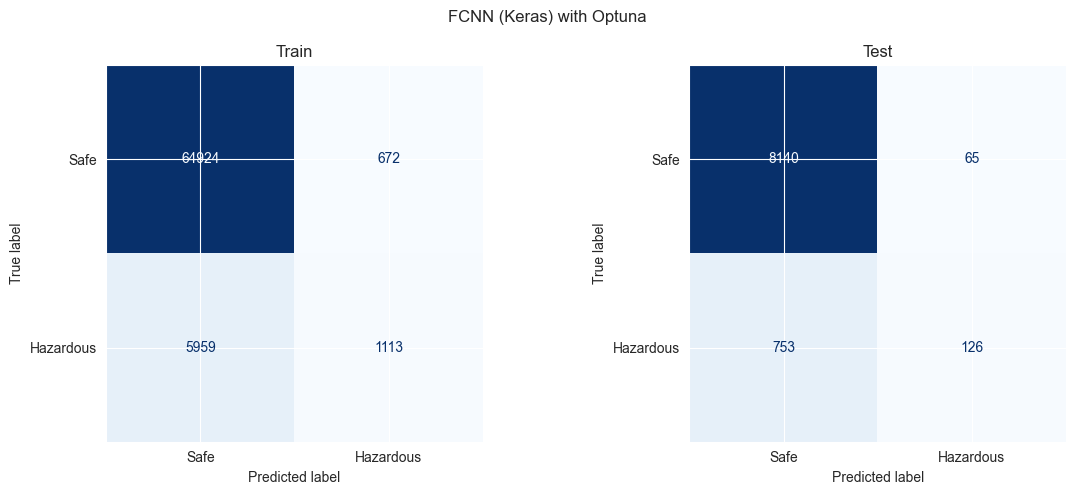

In [104]:
make_graphic_keras(model, "FCNN (Keras) with Optuna")

### KerasTuner

In [105]:
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    activation_choice = hp.Choice("activation", ["relu", "tanh", "elu", "sigmoid"])

    for i in range(hp.Int("n_layers", 1, 5)):
        model.add(layers.Dense(
            units=hp.Int(f"units_{i}", min_value=32, max_value=512, step=32),
            activation=activation_choice
        ))
        if hp.Boolean("dropout"):
            model.add(layers.Dropout(0.2))

    model.add(layers.Dense(1, activation="sigmoid"))

    lr = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer_name = hp.Choice("optimizer", list(optimizers_dict.keys()))
    optimizer = optimizers_dict[optimizer_name](learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [109]:
import keras_tuner as kt
import keras
from keras import layers

tuner = kt.BayesianOptimization(
    build_model,
    objective="val_accuracy",
    max_trials=5,
    overwrite=True,
    project_name="classification_tuning"
)

tuner.search(
    X_train,
    y_train,
    epochs=15,
    validation_data=(X_val, y_val),
    verbose=2,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)]
)

best_model = tuner.get_best_models(num_models=1)[0]
best_params = tuner.get_best_hyperparameters(num_trials=1)[0]


Trial 5 Complete [00h 01m 07s]
val_accuracy: 0.908410370349884

Best val_accuracy So Far: 0.908410370349884
Total elapsed time: 00h 04m 04s


C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [110]:
history = best_model.fit(
    X_train, y_train,
    epochs=25,
    validation_data=(X_val, y_val),
    verbose=2
)

input_into_table_keras(
    name="FCNN (Keras)",
    search_name="KerasTuner (Bayesian)",
    model=best_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    history=history
)


Epoch 1/25
2271/2271 - 5s - 2ms/step - accuracy: 0.9041 - loss: 0.2149 - val_accuracy: 0.9079 - val_loss: 0.2081
Epoch 2/25
2271/2271 - 4s - 2ms/step - accuracy: 0.9033 - loss: 0.2145 - val_accuracy: 0.9069 - val_loss: 0.2062
Epoch 3/25
2271/2271 - 4s - 2ms/step - accuracy: 0.9045 - loss: 0.2235 - val_accuracy: 0.9076 - val_loss: 0.2026
Epoch 4/25
2271/2271 - 4s - 2ms/step - accuracy: 0.9044 - loss: 0.2267 - val_accuracy: 0.9076 - val_loss: 0.2064
Epoch 5/25
2271/2271 - 5s - 2ms/step - accuracy: 0.9051 - loss: 0.2095 - val_accuracy: 0.9003 - val_loss: 0.2186
Epoch 6/25
2271/2271 - 4s - 2ms/step - accuracy: 0.9047 - loss: 0.2102 - val_accuracy: 0.9084 - val_loss: 0.2033
Epoch 7/25
2271/2271 - 4s - 2ms/step - accuracy: 0.9053 - loss: 0.2248 - val_accuracy: 0.9032 - val_loss: 0.2145
Epoch 8/25
2271/2271 - 4s - 2ms/step - accuracy: 0.9042 - loss: 0.2100 - val_accuracy: 0.8656 - val_loss: 0.2525
Epoch 9/25
2271/2271 - 4s - 2ms/step - accuracy: 0.9043 - loss: 0.2086 - val_accuracy: 0.9052 - 

Text(0, 0.5, 'Loss')

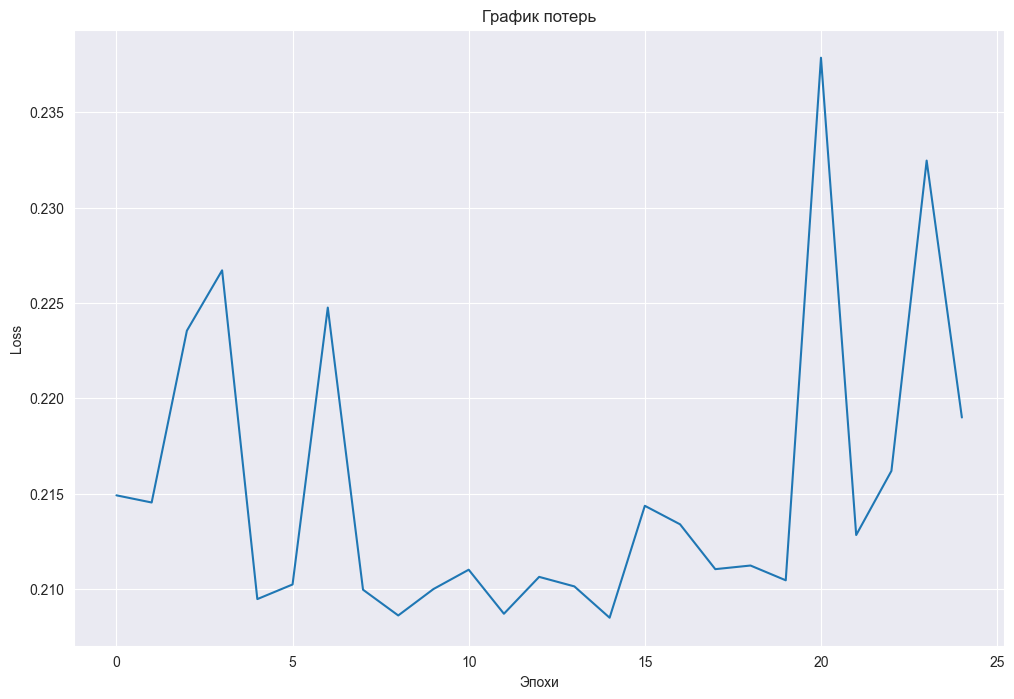

In [111]:
plt.figure(figsize=(12, 8))
plt.plot(history.history['loss'])
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss")

2271/2271 ━━━━━━━━━━━━━━━━━━━━ 1s 625us/step
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step


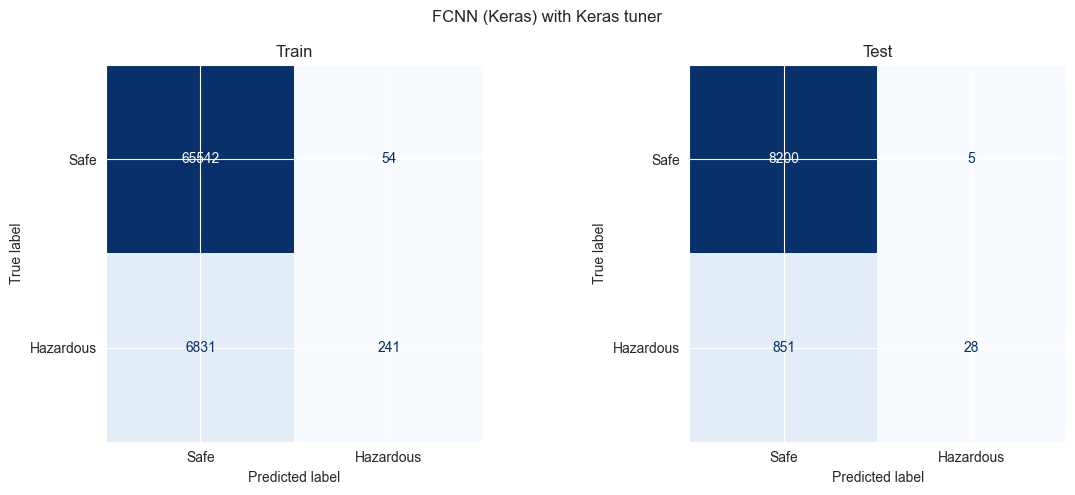

In [112]:
make_graphic_keras(best_model, "FCNN (Keras) with Keras tuner")

In [113]:
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier,Optuna,0.27,0.9107,0.6653,0.15,0.2514,0.9105,0.6757,0.1544,48,adam
1,MLPClassifier,RandomizedSearch,0.28,0.9092,0.6105,0.17,0.2634,0.9086,0.6099,0.1680,41,adam
2,MLPClassifier,Hyperopt,0.28,0.9111,0.6651,0.16,0.2645,0.9109,0.6736,0.1646,103,adam
3,FCNN (Keras),Optuna,0.25,0.9087,0.6235,0.16,0.2355,0.9100,0.6597,0.1433,25,Adam
4,FCNN (Keras),KerasTuner (Bayesian),0.07,0.9053,0.8169,0.03,0.0614,0.9058,0.8485,0.0319,25,RMSprop


In [114]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 352)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        90,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 224)            │       114,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 676,996 (2.58 MB)

 Trainable params: 338,497 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 338,499 (1.29 MB)

In [115]:
from ray import tune
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import numpy as np

def train_model_ray(config):
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_results = []
    opt_map = {
        "adam": tf.keras.optimizers.Adam,
        "sgd": tf.keras.optimizers.SGD,
        "rmsprop": tf.keras.optimizers.RMSprop
    }

    for train_idx, val_idx in kf.split(X_train):
        X_t, X_v = X_train[train_idx], X_train[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = Sequential()
        model.add(layers.Input(shape=(X_t.shape[1],)))

        for i in range(config["n_layers"]):
            model.add(layers.Dense(units=config[f"units_{i}"], activation=config["activation"]))
            model.add(layers.Dropout(config["dropout_rate"]))

        model.add(layers.Dense(1, activation="sigmoid"))

        optimizer = opt_map[config["optimizer"]](learning_rate=config["lr"])
        model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

        model.fit(X_t, y_t, epochs=30, batch_size=32, validation_data=(X_v, y_v), verbose=0)

        y_pred = (model.predict(X_v, verbose=0) > 0.5).astype("int32")
        fold_results.append(f1_score(y_v, y_pred))

    tune.report({"mean_f1": float(np.mean(fold_results))})

search_space = {
    "n_layers": tune.randint(1, 4),
    "activation": tune.choice(["relu", "tanh", "sigmoid"]),
    "dropout_rate": tune.uniform(0.0, 0.3),
    "lr": tune.loguniform(1e-4, 1e-2),
    "optimizer": tune.choice(["adam", "sgd"]),
}

for i in range(4):
    search_space[f"units_{i}"] = tune.qrandint(32, 256, 32)

tuner = tune.Tuner(
    train_model_ray,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        metric="mean_f1",
        mode="max",
        num_samples=15
    )
)

results = tuner.fit()
print("Лучшие параметры:", results.get_best_result().config)


2026-05-11 21:31:49,803	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-11_21-31-41_561073_15432\artifacts\2026-05-11_21-31-49\train_model_ray_2026-05-11_21-31-41\driver_artifacts\train_model_ray_87181_00000_0_activation=sigmoid,dropout_rate=0.2602,lr=0.0063,n_layers=2,optimizer=sgd,units_0=160,units_1=96,uni_2026-05-11_21-31-49
2026-05-11 21:31:49,816	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-11_21-31-41_561073_15432\artifacts\2026-05-11_21-31-49\train_model_ray_2026-05-11_21-31-41\driver_artifacts\train_model_ray_87181_00000_0_activation=sigmoid,dropout_rate=0.2602,lr=0.0063,n_layers=2,optimizer=sgd,units_0=160,units_1=96,uni_2026-05-11_21-31-49
2026-05-11 21:

2026-05-11 21:32:09,171	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-11_21-31-41_561073_15432\artifacts\2026-05-11_21-31-49\train_model_ray_2026-05-11_21-31-41\driver_artifacts\train_model_ray_87181_00003_3_activation=tanh,dropout_rate=0.2271,lr=0.0010,n_layers=1,optimizer=sgd,units_0=32,units_1=64,units_2_2026-05-11_21-31-49
2026-05-11 21:32:09,171	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-11_21-31-41_561073_15432\artifacts\2026-05-11_21-31-49\train_model_ray_2026-05-11_21-31-41\driver_artifacts\train_model_ray_87181_00006_6_activation=tanh,dropout_rate=0.0450,lr=0.0037,n_layers=2,optimizer=adam,units_0=160,units_1=160,unit_2026-05-11_21-31-49
2026-05-11 21:

Лучшие параметры: {'n_layers': 1, 'activation': 'tanh', 'dropout_rate': 0.2637866538633114, 'lr': 0.004589405901447017, 'optimizer': 'adam', 'units_0': 192, 'units_1': 192, 'units_2': 64, 'units_3': 64}


In [116]:
config = results.get_best_result().config
model = keras.Sequential()
model.add(layers.Input(shape=(X_train.shape[1],)))

for i in range(config["n_layers"]):
    model.add(layers.Dense(
        units=config[f"units_{i}"],
        activation=config["activation"]
    ))
    model.add(layers.Dropout(config["dropout_rate"]))

model.add(layers.Dense(1, activation="sigmoid"))

optimizer = optimizers_dict[config["optimizer"]](learning_rate=config["lr"])
model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

input_into_table_keras(
    name="FCNN (Keras)",
    search_name="Ray Tune",
    model=model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    history=history
)


Epoch 1/50
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8914 - loss: 0.2404 - val_accuracy: 0.9021 - val_loss: 0.2332
Epoch 2/50
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 2s 912us/step - accuracy: 0.8938 - loss: 0.2230 - val_accuracy: 0.9021 - val_loss: 0.2157
Epoch 3/50
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 2s 905us/step - accuracy: 0.8974 - loss: 0.2194 - val_accuracy: 0.9021 - val_loss: 0.2287
Epoch 4/50
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 2s 993us/step - accuracy: 0.8947 - loss: 0.2216 - val_accuracy: 0.9064 - val_loss: 0.2057
Epoch 5/50
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8969 - loss: 0.2190 - val_accuracy: 0.9016 - val_loss: 0.2074
Epoch 6/50
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8994 - loss: 0.2146 - val_accuracy: 0.9053 - val_loss: 0.2056
Epoch 7/50
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 2s 930us/step - accuracy: 0.8997 - loss: 0.2149 - val_accuracy: 0.9072 - val_loss: 0.2053
Epoch 8/50
2271/2271 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8954 - loss: 0

In [117]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 192)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,885 (11.27 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,924 (7.52 KB)

In [118]:
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier,Optuna,0.27,0.9107,0.6653,0.15,0.2514,0.9105,0.6757,0.1544,48,adam
1,MLPClassifier,RandomizedSearch,0.28,0.9092,0.6105,0.17,0.2634,0.9086,0.6099,0.1680,41,adam
2,MLPClassifier,Hyperopt,0.28,0.9111,0.6651,0.16,0.2645,0.9109,0.6736,0.1646,103,adam
3,FCNN (Keras),Optuna,0.25,0.9087,0.6235,0.16,0.2355,0.9100,0.6597,0.1433,25,Adam
4,FCNN (Keras),KerasTuner (Bayesian),0.07,0.9053,0.8169,0.03,0.0614,0.9058,0.8485,0.0319,25,RMSprop
5,FCNN (Keras),Ray Tune,0.21,0.9077,0.6264,0.13,0.2105,0.9092,0.6627,0.1251,50,Adam


Text(0, 0.5, 'Loss (MSE)')

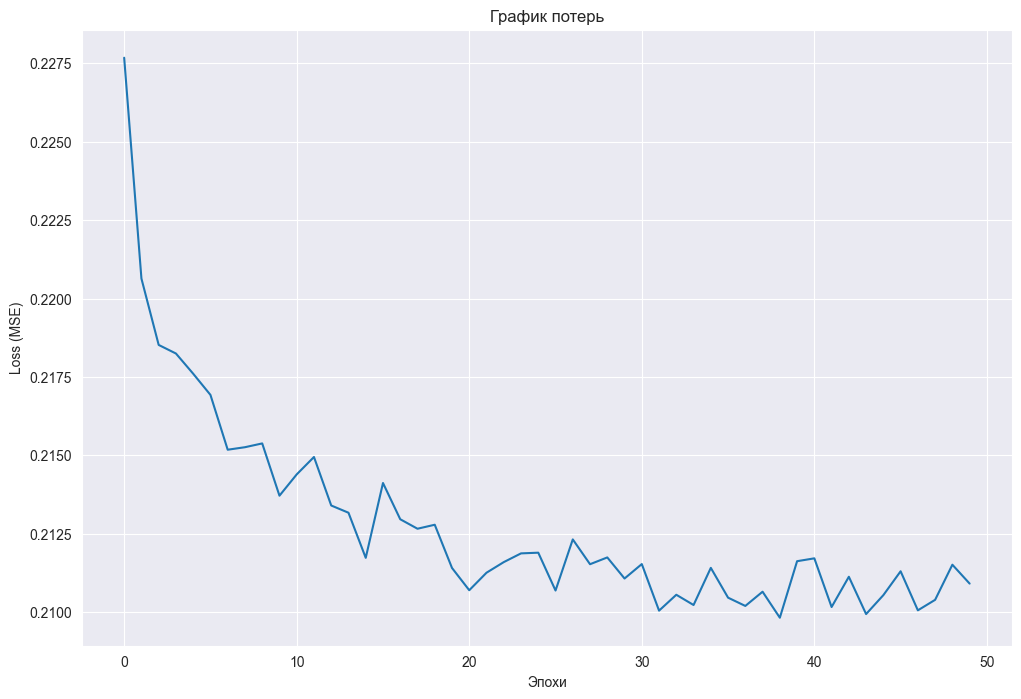

In [119]:
plt.figure(figsize=(12, 8))
plt.plot(history.history['loss'])
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss (MSE)")

2271/2271 ━━━━━━━━━━━━━━━━━━━━ 1s 456us/step
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step


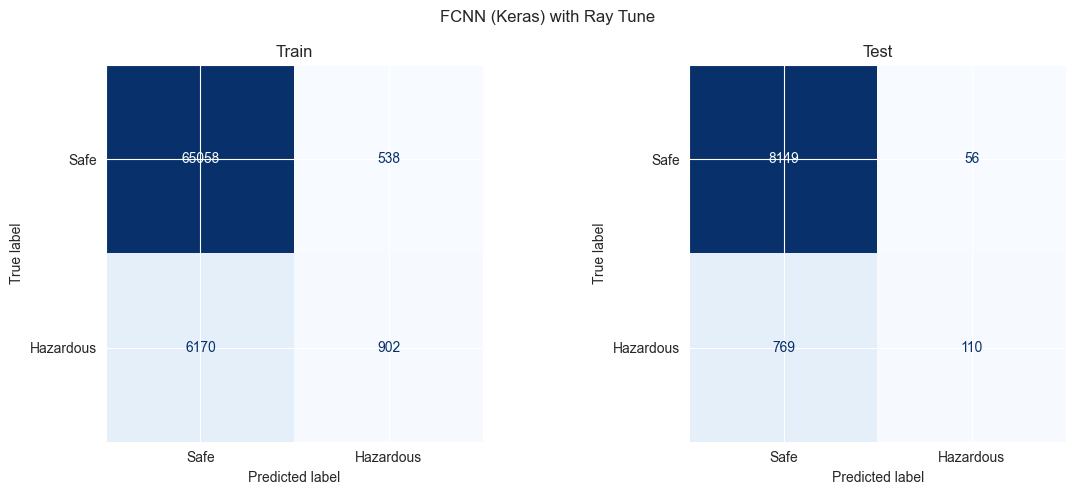

In [120]:
make_graphic_keras(model, "FCNN (Keras) with Ray Tune")

In [121]:
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier,Optuna,0.27,0.9107,0.6653,0.15,0.2514,0.9105,0.6757,0.1544,48,adam
1,MLPClassifier,RandomizedSearch,0.28,0.9092,0.6105,0.17,0.2634,0.9086,0.6099,0.1680,41,adam
2,MLPClassifier,Hyperopt,0.28,0.9111,0.6651,0.16,0.2645,0.9109,0.6736,0.1646,103,adam
3,FCNN (Keras),Optuna,0.25,0.9087,0.6235,0.16,0.2355,0.9100,0.6597,0.1433,25,Adam
4,FCNN (Keras),KerasTuner (Bayesian),0.07,0.9053,0.8169,0.03,0.0614,0.9058,0.8485,0.0319,25,RMSprop
5,FCNN (Keras),Ray Tune,0.21,0.9077,0.6264,0.13,0.2105,0.9092,0.6627,0.1251,50,Adam


In [123]:
sample_data = np.array([[
    1.25,
    0.3,
    0.2,
]], dtype='float32')

prediction = best_model.predict(sample_data)
print(f"Результат предсказания: {prediction[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Результат предсказания: [0.]
